In [1]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]

Python executable:
c:\Users\DELL\Cognifyz-Data-Analysis\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!


# Level 1 - Task 1: Top Cuisines

## Objective

Determine the top three most common cuisines in the dataset and calculate the percentage of restaurants that serve each of the top cuisines.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [13]:
df = pd.read_csv("../Dataset/Dataset.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 9551
Number of columns: 21


In [14]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [15]:
print(df.columns.tolist())

['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [18]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (9551, 21)

Columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [19]:
print("Missing values in Cuisines:", df["Cuisines"].isnull().sum())

Missing values in Cuisines: 9


In [20]:
cuisine_data = df["Cuisines"].fillna("Unknown")

print("Missing values after handling:", cuisine_data.isnull().sum())

Missing values after handling: 0


In [21]:
cuisine_counts = (
    cuisine_data
    .str.split(", ")
    .explode()
    .value_counts()
)

print("Top 10 cuisines:")
print(cuisine_counts.head(10))

Top 10 cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64


In [22]:
top_3_cuisines = cuisine_counts.head(3)

print("Top 3 Cuisines:")
print(top_3_cuisines)

Top 3 Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


In [23]:
total_restaurants = len(df)

top_3_percentage = (
    top_3_cuisines / total_restaurants
) * 100

print("Percentage of restaurants serving each top cuisine:")
print(top_3_percentage.round(2))

Percentage of restaurants serving each top cuisine:
Cuisines
North Indian    41.46
Chinese         28.64
Fast Food       20.79
Name: count, dtype: float64


In [24]:
top_cuisine_result = pd.DataFrame({
    "Cuisine": top_3_cuisines.index,
    "Restaurant Count": top_3_cuisines.values,
    "Percentage": top_3_percentage.values
})

top_cuisine_result["Percentage"] = (
    top_cuisine_result["Percentage"].round(2)
)

top_cuisine_result

,Cuisine,Restaurant Count,Percentage
0,North Indian,3960,41.46
1,Chinese,2735,28.64
2,Fast Food,1986,20.79


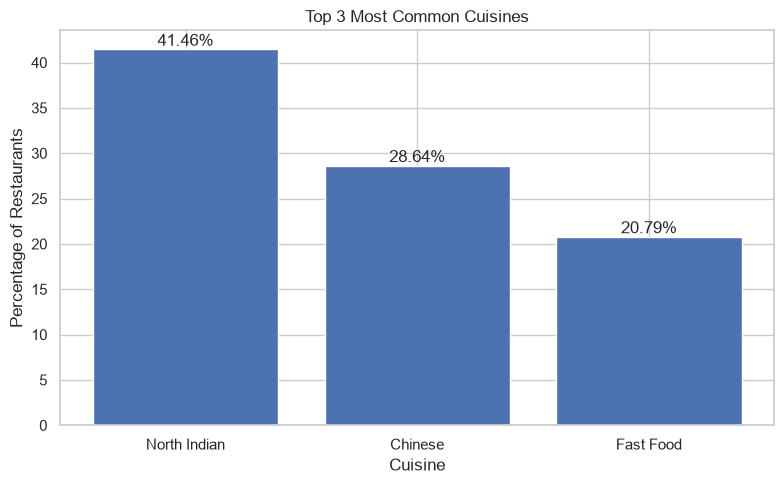

In [25]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    top_cuisine_result["Cuisine"],
    top_cuisine_result["Percentage"]
)

plt.title("Top 3 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Percentage of Restaurants")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "top_cuisines.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusion

The analysis identified the three most common cuisines in the restaurant dataset.

The most commonly served cuisine was **North Indian**, followed by **Chinese** and **Fast Food**.

Among the top three cuisines, **North Indian** had the highest representation, being served by **3960 restaurants**, which accounts for approximately **41.46%** of all restaurants in the dataset.

# Level 1 - Task 2: City Analysis

## Objective

Identify the city with the highest number of restaurants in the dataset. Calculate the average rating for restaurants in each city. Determine the city with the highest average rating.

In [29]:
print("Missing city values:", df["City"].isnull().sum())
print("\nNumber of unique cities:", df["City"].nunique())

Missing city values: 0

Number of unique cities: 141


In [30]:
city_counts = df["City"].value_counts()

print("Top 10 cities by number of restaurants:")
print(city_counts.head(10))

Top 10 cities by number of restaurants:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64


In [31]:
top_city = city_counts.idxmax()
top_city_count = city_counts.max()

print("City with the highest number of restaurants:", top_city)
print("Number of restaurants:", top_city_count)

City with the highest number of restaurants: New Delhi
Number of restaurants: 5473


In [32]:
city_rating = (
    df.groupby("City")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 cities by average rating:")
print(city_rating.head(10).round(2))

Top 10 cities by average rating:
City
Inner City          4.90
Quezon City         4.80
Makati City         4.65
Pasig City          4.63
Mandaluyong City    4.62
Beechworth          4.60
London              4.54
Taguig City         4.53
Secunderabad        4.50
Lincoln             4.50
Name: Aggregate rating, dtype: float64


In [33]:
city_analysis = df.groupby("City").agg(
    Restaurant_Count=("Restaurant ID", "count"),
    Average_Rating=("Aggregate rating", "mean")
)

city_analysis["Average_Rating"] = city_analysis["Average_Rating"].round(2)

city_analysis = city_analysis.sort_values(
    "Restaurant_Count",
    ascending=False
)

city_analysis.head(10)

,Restaurant_Count,Average_Rating
City,,
New Delhi,5473,2.44
Gurgaon,1118,2.65
Noida,1080,2.04
Faridabad,251,1.87
Ghaziabad,25,2.85
Bhubaneshwar,21,3.98
Lucknow,21,4.20
Guwahati,21,4.19
Ahmedabad,21,4.16


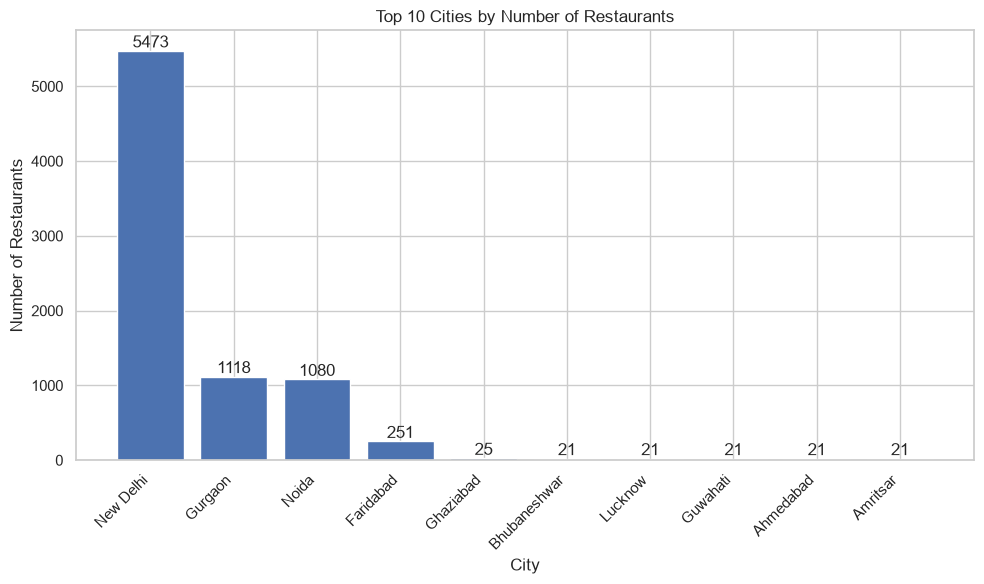

In [34]:
top_10_cities = city_analysis.head(10)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    top_10_cities.index,
    top_10_cities["Restaurant_Count"]
)

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "city_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
print("City with highest number of restaurants:")
print(top_city)

print("\nNumber of restaurants:")
print(top_city_count)

print("\nAverage rating of that city:")
print(round(city_analysis.loc[top_city, "Average_Rating"], 2))

City with highest number of restaurants:
New Delhi

Number of restaurants:
5473

Average rating of that city:
2.44


## Conclusion

New Delhi has the highest number of restaurants in the dataset, with **5,473 restaurants**.

The average restaurant rating in New Delhi is **2.44**. This indicates that although New Delhi has a very large number of restaurants, the average rating is relatively moderate.

# Level 1 - Task 3: Price Range Distribution

## Objective

Create a histogram or bar chart to visualize the distribution of price ranges among the restaurants. Calculate the percentage of restaurants in each price range category.

In [36]:
print("Unique price ranges:")
print(sorted(df["Price range"].dropna().unique()))

Unique price ranges:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [37]:
price_counts = df["Price range"].value_counts().sort_index()

print("Restaurants by price range:")
print(price_counts)

Restaurants by price range:
Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


In [38]:
price_percentage = (
    price_counts / len(df)
) * 100

price_percentage = price_percentage.round(2)

print("Percentage of restaurants in each price range:")
print(price_percentage)

Percentage of restaurants in each price range:
Price range
1    46.53
2    32.59
3    14.74
4     6.14
Name: count, dtype: float64


In [39]:
price_analysis = pd.DataFrame({
    "Price Range": price_counts.index,
    "Restaurant Count": price_counts.values,
    "Percentage": price_percentage.values
})

price_analysis

,Price Range,Restaurant Count,Percentage
0,1,4444,46.53
1,2,3113,32.59
2,3,1408,14.74
3,4,586,6.14


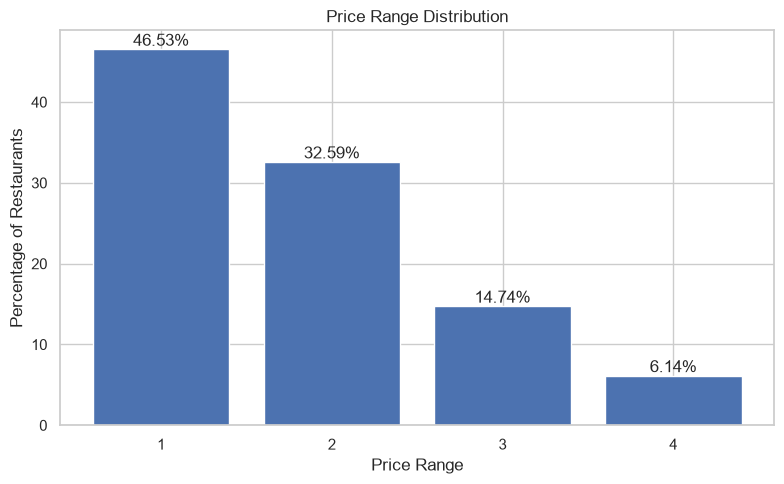

In [40]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    price_analysis["Price Range"].astype(str),
    price_analysis["Percentage"]
)

plt.title("Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
most_common_price_range = price_counts.idxmax()
most_common_price_count = price_counts.max()
most_common_price_percentage = price_percentage.loc[
    most_common_price_range
]

print("Most common price range:", most_common_price_range)
print("Number of restaurants:", most_common_price_count)
print("Percentage:", most_common_price_percentage, "%")

Most common price range: 1
Number of restaurants: 4444
Percentage: 46.53 %


## Conclusion

The analysis shows that **Price Range 1** is the most common price category in the dataset.

There are **4,444 restaurants** in this category, representing approximately **46.53%** of all restaurants.

This indicates that lower-priced restaurants have the largest representation in the dataset.

# Level 1 - Task 4: Online Delivery

## Objective

Determine the percentage of restaurants that offer online delivery. Compare the average ratings of restaurants
with and without online delivery.

In [42]:
print(df["Has Online delivery"].value_counts())

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64


In [43]:
delivery_counts = df["Has Online delivery"].value_counts()

delivery_percentage = (
    delivery_counts / len(df)
) * 100

print("Online Delivery Distribution:")
print(delivery_percentage.round(2))

Online Delivery Distribution:
Has Online delivery
No     74.34
Yes    25.66
Name: count, dtype: float64


In [44]:
delivery_ratings = (
    df.groupby("Has Online delivery")["Aggregate rating"]
    .mean()
    .round(2)
)

print("Average rating by online delivery availability:")
print(delivery_ratings)

Average rating by online delivery availability:
Has Online delivery
No     2.47
Yes    3.25
Name: Aggregate rating, dtype: float64


In [45]:
online_delivery_analysis = pd.DataFrame({
    "Online Delivery": delivery_counts.index,
    "Restaurant Count": delivery_counts.values,
    "Percentage": delivery_percentage.round(2).values,
    "Average Rating": [
        delivery_ratings.loc[x] for x in delivery_counts.index
    ]
})

online_delivery_analysis

,Online Delivery,Restaurant Count,Percentage,Average Rating
0,No,7100,74.34,2.47
1,Yes,2451,25.66,3.25


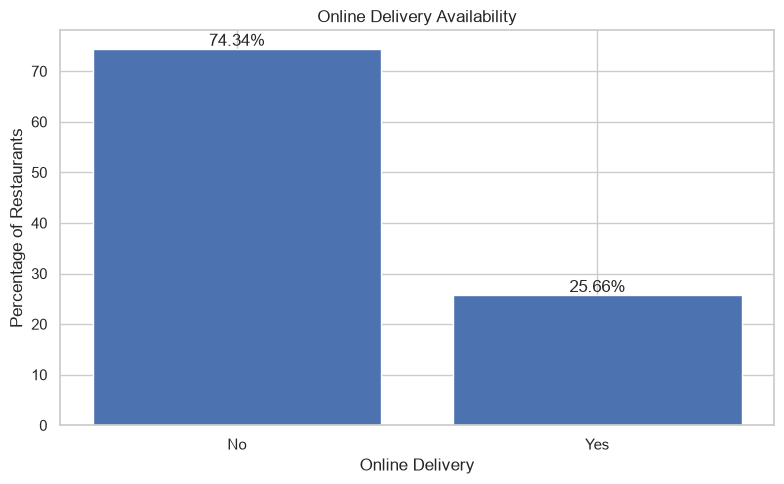

In [46]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    online_delivery_analysis["Online Delivery"],
    online_delivery_analysis["Percentage"]
)

plt.title("Online Delivery Availability")
plt.xlabel("Online Delivery")
plt.ylabel("Percentage of Restaurants")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "online_delivery.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
delivery_ratings = (
    df.groupby("Has Online delivery")["Aggregate rating"]
    .mean()
    .round(2)
)

print("Average rating by online delivery:")
print(delivery_ratings)

Average rating by online delivery:
Has Online delivery
No     2.47
Yes    3.25
Name: Aggregate rating, dtype: float64


## Conclusion

The analysis shows that **2,451 restaurants (25.66%)** offer online delivery, while **7,100 restaurants (74.34%)** do not offer online delivery.

Restaurants that offer online delivery have an average rating of **3.25**, compared with **2.47** for restaurants without online delivery.

Therefore, restaurants offering online delivery have a **higher average rating** than restaurants without online delivery, with a difference of approximately **0.78 rating points**.